In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/master_dataset.csv")

X = df[["yield", "avg_temp", "rainfall", "pesticides"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
1    17067
2     6333
0     4848
Name: count, dtype: int64

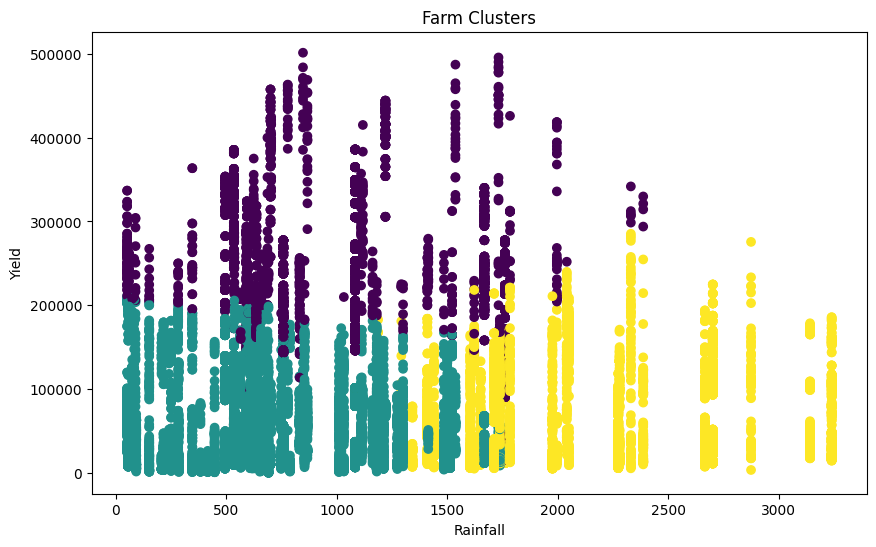

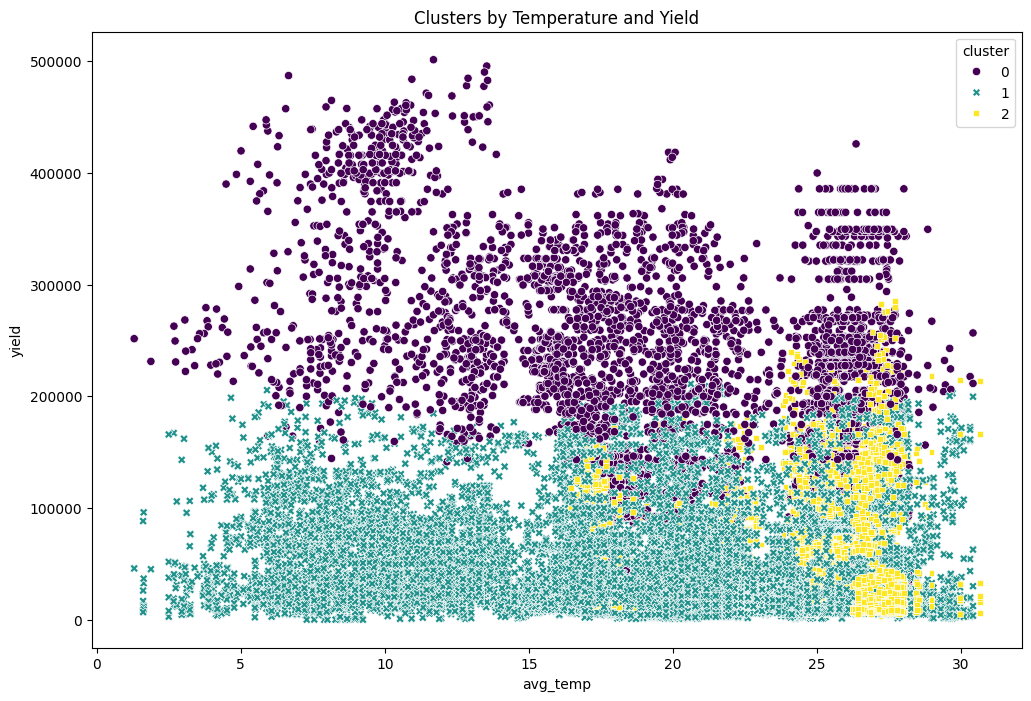

In [5]:
import seaborn as sns
plt.figure(figsize=(10,6))
plt.scatter(df["rainfall"], df["yield"], c=df["cluster"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Farm Clusters")
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x="avg_temp", y="yield", hue="cluster", style="cluster", palette="viridis")
plt.title("Clusters by Temperature and Yield")
plt.show()

In [6]:
from sklearn.ensemble import IsolationForest

features = df[["yield", "avg_temp", "rainfall", "pesticides"]]

iso = IsolationForest(contamination=0.03, random_state=42)

df["anomaly"] = iso.fit_predict(features)

In [7]:
df["anomaly"].value_counts()

anomaly
 1    27400
-1      848
Name: count, dtype: int64

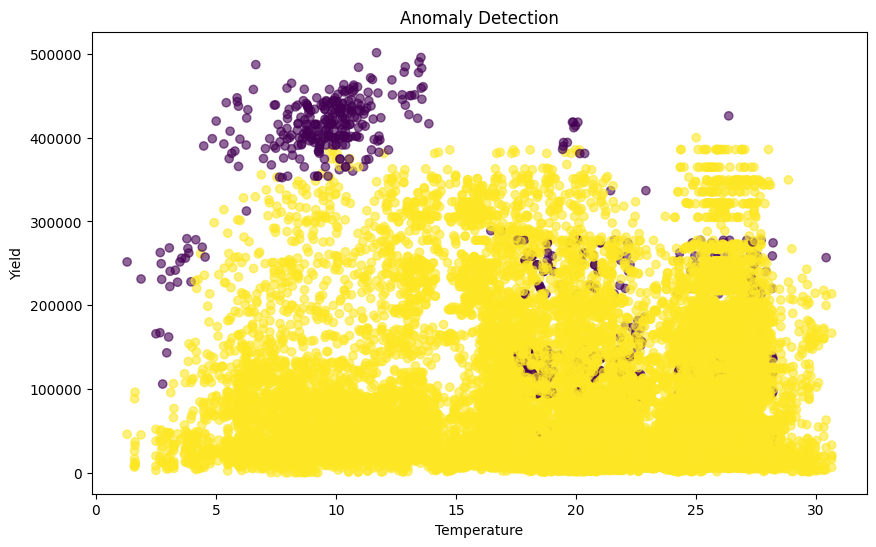

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(
    df["avg_temp"],
    df["yield"],
    c=df["anomaly"],
    alpha=0.6
)
plt.title("Anomaly Detection")
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.show()